### Predicting Petal Length from Sepal Length using Linear Regression

In [19]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn import linear_model

# Load a real dataset
from sklearn.datasets import load_iris
df = pd.DataFrame(load_iris().data, columns=load_iris().feature_names)


In [20]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [21]:
df.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


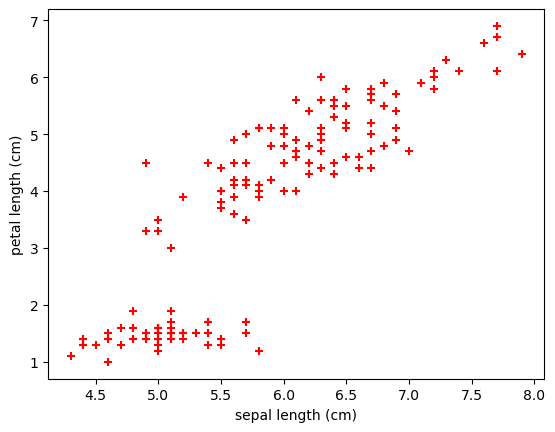

In [23]:
# Applying scatter plot to see if there is linear relation exists between sepal length and petal length

plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.scatter(df['sepal length (cm)'],df['petal length (cm)'],color='red',marker='+')
plt.show()

In [24]:
# correlation gives the measure of how strong the linear relationship between two variable is -1 <= r <= +1

correlation = df['sepal length (cm)'].corr(df['petal length (cm)'])
print(correlation)

0.8717537758865831


In [25]:
# Prepare your data
X = df[['sepal length (cm)']]  # input
y = df['petal length (cm)']    # output

In [26]:
from sklearn.model_selection import train_test_split

# Split the data into 80% training and 20% testing 
#This allows 20% of the data is unexposed to the training set so that we can apply on test data to check our prediction works fine
# random_state=42 ensures we get the same split every time we run

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# Check the size of each split
print("Training size:", len(X_train))
print("Testing size:", len(X_test))

Training size: 120
Testing size: 30


In [28]:
# Create and fit the model
model = linear_model.LinearRegression()
model.fit(X, y)
print('Model Trained!')

Model Trained!


In [29]:
# See the result
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 1.8584329782548412
Intercept: -7.101443369602455


In [31]:
# Predict petal length using the TEST data the model has never seen
y_pred = model.predict(X_test)

print("Predicted:", y_pred[:5])         # checking our first 5 predicted values out of 30
print("Actual:   ", list(y_test[:5]))   # checking our first 5 Actual values out of 30

Predicted: [4.2349978  3.49162461 7.20849056 4.0491545  5.53590088]
Actual:    [4.7, 1.7, 6.9, 4.5, 4.8]


##### Overall the model performs reasonably well given we used only one feature (sepal length)
##### Most predictions are within 0.5cm of the actual value
##### Some outliers exist (eg: predicted 3.49 vs actual 1.7) which is expected in real world data
##### Model accuracy will improve when we add more features (multiple regression) 

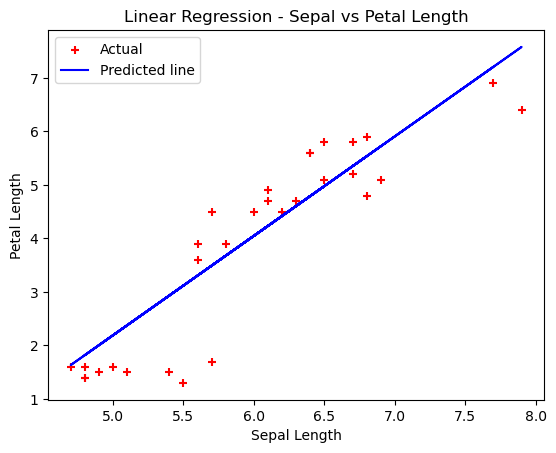

In [32]:
# Plot the original scatter of TEST data
plt.scatter(X_test, y_test, color='red', label='Actual', marker='+')

# Draw the regression line using predictions
plt.plot(X_test, y_pred, color='blue', label='Predicted line')

plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.title('Linear Regression - Sepal vs Petal Length')
plt.legend()
plt.show()

In [33]:
# mean_Squared_error allows us to find how far is our predicted line from the each actual data points

from sklearn.metrics import mean_squared_error

# Calculate MSE on test data

mse = mean_squared_error(y_test,y_pred) # applying on test and predicted values

print("Mean Squared Error:", mse)

Mean Squared Error: 0.5833805544857861


##### =============================================================
##### CONCLUSION - Linear Regression: Sepal Length vs Petal Length (comments section drafted using GPT)
##### =============================================================

##### Dataset   : Iris dataset (150 flowers, 3 species)
##### Input (X) : Sepal Length
##### Output (y): Petal Length

##### Step 1 - Explored the data using a scatter plot
##### Step 2 - Found a strong positive correlation of 0.8 between sepal and petal length
##### Step 3 - Split data into 80% training (120 flowers) and 20% testing (30 flowers)
##### Step 4 - Trained a Linear Regression model on training data
##### Step 5 - Predicted petal lengths on unseen test data
##### Step 6 - Visualized the regression line against actual test data

##### Findings:
##### - The model learned a meaningful pattern from sepal length alone
##### - Most predictions were within 0.5cm of actual values
##### - Some outliers exist which is expected in real world data
##### - A stronger model can be built using multiple features (multiple regression)

##### Next steps:
##### - Measure accuracy formally using Mean Squared Error
##### - Try multiple regression with all features
##### - Explore classification models on the same dataset
##### =============================================================